<a href="https://colab.research.google.com/github/SampMark/Deep-Learning/blob/main/Transformers_for_Text_Generation_consolided.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Geração de Texto com Transformers no TensorFlow/Keras**

Este notebook demonstra a implementação de um modelo básico Transformer para geração de texto,
utilizando o TensorFlow e API Keras. O código foi organizado em etapas para facilitar
o entendimento e a experimentação.

**Etapas Principais:**

1.  **Pré-processamento de Texto:**
    * Carregamento do _dataset_ de texto (Shakespeare).
    * Vetorização usando a camada `TextVectorization`.
    * Criação de sequências de entrada e saída para treinamento do modelo.

2.  **Definição do Modelo Transformer:**
    * Implementação do bloco `TransformerBlock` com atenção multi-cabeça e redes _feed-forward_.
    * Construção do modelo `TransformerModel` completo, incluindo _embedding_, codificação posicional e camadas densas.

3.  **Treinamento do Modelo:**
    * Compilação do modelo com otimizador `adam` e função de perda `SparseCategoricalCrossentropy`.
    * Utilização de técnicas de regularização como `Dropout` e *Early Stopping*.
    * Implementação de um *Learning Rate Scheduler* para otimizar o treinamento.

4.  **Geração de Texto:**
    * Função para gerar texto a partir de uma sequência inicial ("seed text").

In [1]:
# @title **Instalação e importações**
!pip install tensorflow

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
# Importações específicas do Keras/TensorFlow para construir o modelo
from tensorflow.keras.layers import (
    Layer, Input, Dense, TextVectorization, Embedding,
    LayerNormalization, Dropout, MultiHeadAttention
)
from tensorflow.keras.models import Model
from tensorflow.keras.utils import get_file
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.optimizers.schedules import CosineDecay
# from tensorflow.keras.mixed_precision import set_global_policy
# set_global_policy('mixed_float32')

In [3]:
# @title **Verificação de GPU**
# =====================
# Ao treinar modelos grandes como Transformers será necessário uma GPUs
# No ambiente de execução aloque uma GPU
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU alocada: {gpu_devices}")
else:
    print("Nenhuma GPU alocada.")

GPU alocada: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# Carregamento e Pré-processamento do Dataset
# =============================================
# @title Etapa 1: **Carregar e pré-processar o dataset...**
path_to_file = get_file('shakespeare.txt', 'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt')
text = open(path_to_file, 'rb').read().decode(encoding='utf-8')
print(text[:1000])

1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this 

In [33]:
print(text[:2200])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



In [8]:
# Configuração dos parâmetros do modelo e pré-processamento
vocab_size = 10000  # Tamanho máximo do vocabulário (palavras mais frequentes)
seq_length = 100    # Comprimento das sequências de entrada/saída
embed_dim = 256     # Dimensão dos vetores de embedding (representação das palavras)
num_heads = 4       # Número de cabeças de atenção no MultiHeadAttention
ff_dim = 512        # Dimensão da camada interna da rede Feed-Forward no TransformerBlock
num_layers = 4      # Número de TransformerBlocks empilhados no modelo

# Cria a camada de TextVectorization
vectorizer = TextVectorization(
    max_tokens=vocab_size,    # Limita o vocabulário às 'vocab_size' palavras mais comuns
    output_mode='int',        # Saída será números inteiros (índices das palavras)
    standardize=None          # Não aplica padronização (lowercase, pontuação) - Mantém o texto original
)

# Adapta a camada ao texto para construir o vocabulário
text_ds = tf.data.Dataset.from_tensor_slices([text]).batch(1) # Cria um Dataset TensorFlow com o texto
vectorizer.adapt(text_ds) # Analisa o texto e cria o mapeamento palavra -> índice

# Vetoriza (transforma em números) o texto completo
vectorized_text = vectorizer([text])[0] # Aplica a vetorização

# Exibe informações sobre o texto vetorizado
print("\nFormato de texto vetorizado:", vectorized_text.shape)
print("Exibir os 10 primeiros tokens vetorizados:", vectorized_text.numpy()[:10])


Formato de texto vetorizado: (202651,)
Exibir os 10 primeiros tokens vetorizados: [ 110  248  749   39 2486  144 4854  146   24  616]


## **Etapa 2: Criação de Sequências de Treinamento (X, Y)**


---


Nesta etapa, tem por objetivo treinar um modelo de linguagem para prever a próxima palavra (ou _token_) em uma sequência. Para isso, precisamos de pares de (sequência de entrada, sequência de saída esperada).

* A função `create_sequences` gera pares de sequências onde X é uma porção do texto e Y é a mesma porção deslocada em um passo. O que é adequado para modelagem de linguagem, cujo objetivo é prever o próximo token em uma sequência.
* O parâmetro `step` permite controlar o espaçamento entre as sequências geradas.
* O código então chama `create_sequences` para gerar as sequências a partir do texto vetorizado.
* Verificações (`asserts`) garantem que os dados sejam válidos.
* Os arrays NumPy `X` e `Y` são convertidos em tensores TensorFlow.

In [9]:
# @title **Função `create_sequences`**
def create_sequences(text, seq_length, step=5):
    """
    Gera sequências de entrada e saída a partir de um texto.

    Esta função cria pares de sequências onde a sequência de entrada (X)
    é uma porção do texto e a sequência de saída (Y) é a mesma porção
    deslocada em um passo. Isso é útil para tarefas de modelagem de linguagem,
    onde o objetivo é prever o próximo elemento em uma sequência.

    Args:
        text: Uma lista de tokens (inteiros) representando o texto.
        seq_length: O comprimento desejado para as sequências de entrada.
        step: O número de tokens para avançar ao criar cada nova sequência.
              Um valor maior que 1 cria sequências sobrepostas.

    Returns:
        Um par de arrays NumPy (X, Y), onde:
            X: Array de sequências de entrada, com forma (num_sequências, seq_length).
            Y: Array de sequências de saída (os "targets"), com a mesma forma de X.
               Y é X deslocado em um token.
    """

    input_seqs = []
    target_seqs = []

    # Itera sobre o texto com um passo definido para criar as sequências
    for i in range(0, len(text) - seq_length, step):
        input_seq = text[i:i + seq_length]      # Sequência de entrada
        target_seq = text[i + 1:i + seq_length + 1] # Sequência de saída (deslocada em 1)

        input_seqs.append(input_seq)
        target_seqs.append(target_seq)

    return np.array(input_seqs), np.array(target_seqs)

In [11]:
# Gera as sequências a partir do texto vetorizado
X, Y = create_sequences(vectorized_text.numpy(), seq_length, step=5)

print("\nNúmero de sequências geradas:", len(X))
print("Sequências de entrada (amostra X[0]):", X[0] if len(X) > 0 else "Nenhuma sequência gerada")
print("Sequências de saída (amostra Y[0]):", Y[0] if len(Y) > 0 else "Nenhuma sequência gerada")


# Asserts para garantir que os dados sejam válidos
assert X.size > 0, "Não há dados de entrada X"
assert Y.size > 0, "Não há dados de destino Y"
assert X.shape == Y.shape, "X e Y devem ter o mesmo formato"

# Converção dos arrays NumPy para tensores TensorFlow
X = tf.convert_to_tensor(X, dtype=tf.int64)
Y = tf.convert_to_tensor(Y, dtype=tf.int64)

print("\nFormato de X (TensorFlow):", X.shape)
print("Formato de Y (TensorFlow):", Y.shape)


Número de sequências geradas: 40511
Sequências de entrada (amostra X[0]): [ 110  248  749   39 2486  144 4854  146   24  616 1181 3507  616  110
  248   75   38   37 2211  419    4  398   70    4    1 1181    1    1
  110  248 1122    9   88 1575  773   13 3423 1222    4    2 1731 1181
  142    1   39 6095  110  248  198   93  552  152    5  509   20 3410
   50   35  181    1 1822    8    1 1181  258   62 4390 8296   79   21
   17 1914 1447 1552  172  248  527  957   48 9702  110  248  142   38
    1  188 3419    2 4603 1634   63 3464    1   47   53 5768 1473   49
   57   53]
Sequências de saída (amostra Y[0]): [ 248  749   39 2486  144 4854  146   24  616 1181 3507  616  110  248
   75   38   37 2211  419    4  398   70    4    1 1181    1    1  110
  248 1122    9   88 1575  773   13 3423 1222    4    2 1731 1181  142
    1   39 6095  110  248  198   93  552  152    5  509   20 3410   50
   35  181    1 1822    8    1 1181  258   62 4390 8296   79   21   17
 1914 1447 1552  172  248

## **Etapa 3: Componentes do Transformer:** codificação posicional e máscara _Look-Ahead_

---



Esta seção define as funções auxiliares para a codificação posicional e a criação de máscaras de *look-ahead*, que são componentes importantes da arquitetura Transformer.

#### **1. Codificação Posicional**: Função `positional_encoding`

Os Transformers não possuem recorrência, logo precisam de alguma forma para incorporar informações sobre a posição das palavras na sequência. A codificação posicional adiciona um vetor a cada _embedding_ de palavra.

**Por quê?**
O mecanismo de atenção do Transformer processa todos os tokens da sequência de uma vez, sem uma noção inerente de ordem (diferente das RNNs que processam sequencialmente). A codificação posicional injeta informação sobre a posição de cada token na sequência.

**Como?** Criando um vetor de mesmo tamanho que o _embedding_ `(embed_dim)` para cada posição na sequência `(seq_len)`.

Esses vetores são calculados usando as funções seno e cosseno com diferentes frequências. A ideia é que cada posição tenha um "código" posicional único que o modelo possa aprender a usar.
A função calcula esses valores usando as fórmulas do artigo seminal "_Attention Is All You Need_" e retorna um tensor de shape `(1, seq_len, embed_dim)`. A primeira dimensão (1) é para _broadcasting_, ou seja, para facilitar a soma com os _embeddings_ do _batch_.



In [14]:
# @title **Função `positional_encoding`**
def positional_encoding(seq_len, embed_dim):
    """Gera a matriz de codificação posicional sinusoidal."""
    pos = tf.range(seq_len, dtype=tf.float32)[:, tf.newaxis]
    i = tf.range(embed_dim, dtype=tf.float32)[tf.newaxis, :]

    # Fórmula da codificação posicional (seno para posições pares, cosseno para ímpares)
    angle_rates = 1 / tf.pow(10000.0, (2 * (i // 2)) / tf.cast(embed_dim, tf.float32))
    angle_rads = pos * angle_rates

    # Aplica seno nas colunas pares (índice 0, 2, ...) e cosseno nas ímpares (1, 3, ...)
    sines = tf.sin(angle_rads[:, 0::2])
    cosines = tf.cos(angle_rads[:, 1::2])

    # Intercala senos e cossenos
    # Garante que o shape final seja (1, seq_len, embed_dim)
    pos_encoding_tensor = tf.concat([sines, cosines], axis=-1)

    # Adiciona uma dimensão de batch no início e garante float32
    pos_encoding_tensor = pos_encoding_tensor[tf.newaxis, ...]

    return tf.cast(pos_encoding_tensor, dtype=tf.float32)

### **2. Máscara _Look-Ahead_**

Em tarefas de geração de texto, é importante que o modelo não "olhe para o futuro" ao prever o próximo _token_. A máscara *look-ahead* garante que a atenção em uma determinada posição só possa ser calculada sobre as posições anteriores.

**Por quê?** Durante o treinamento para que o modelo possa prever o próximo token, ele não pode ter acesso aos _tokens_ futuros da sequência de saída (Y), isto seria como "colar". A máscara look-ahead (ou máscara causal) garante que, ao calcular a atenção para uma posição $i$, o modelo só possa "prestar atenção" às posições de 0 a i (incluindo i) e não às posições i+1, i+2, etc.

**Como?**
* `tf.ones((size, size))` cria uma matriz quadrada de 1s.
* `tf.linalg.band_part(..., -1, 0)` mantém a diagonal principal e tudo abaixo dela (triângulo inferior), zerando o resto.
* `1 - ...` inverte a máscara, onde era 1 (permitido) vira 0, e onde era 0 (ignorado) vira 1. Assim a camada `MultiHeadAttention` do Keras espera que os valores a serem mascarados (ignorados) sejam 1 (ou True).
* Retorna uma matriz `(size, size)` onde size é o comprimento da sequência.

In [15]:
# @title **Função `create_look_ahead_mask`**
def create_look_ahead_mask(size):
    """Cria a máscara para impedir a atenção a tokens futuros."""

    # Cria uma matriz triangular inferior de uns
    mask = 1 - tf.linalg.band_part(tf.ones((size, size)), -1, 0)

    # Retorna a máscara (0 onde a atenção é permitida, 1 onde é mascarada)
    return mask

## **Etapa 3: Definição da Arquitetura do Modelo Transformer**

Esta etapa define as classes `TransformerBlock` e `TransformerModel`, que implementam a arquitetura do modelo Transformer.

### **Classe `TransformerBlock`**

Representa um único bloco do Transformer, que consiste em:
  * Uma camada de atenção multi-cabeça (`MultiHeadAttention`).
  * Uma rede neural *feed-forward* densa.
  * Camadas de normalização(`LayerNormalization`).
  * Camadas de *dropout* (`Dropout`) para regularização.
  * Conexões residuais para facilitar o fluxo de gradiente.
  * O método `call` executa a passagem para frente do bloco.

#### **Funcionamento do `TransformerBlock`

* `__init__` (inicialização) define as camadas que compõem um bloco:
  * `MultiHeadAttention`: é o coração do Transformer, permite que o modelo pese a importância de diferentes tokens na sequência ao processar um token específico. "Multi-cabeça" significa que ele faz isso de várias maneiras diferentes (cabeças) em paralelo, capturando diferentes tipos de relações. Neste caso (modelo decoder/gerador), é self-attention (atenção a si mesmo), pois a entrada (query, key, value) é a mesma sequência.
  * `ffn`: uma rede feed-forward simples (duas camadas densas com ativação ReLU no meio) aplicada a cada posição da sequência independentemente. Ajuda a processar a informação obtida pela atenção.
  * `LayerNormalization`: normaliza as ativações dentro de cada camada, ajudando a estabilizar e acelerar o treinamento.
  * `Dropout`: zera aleatoriamente algumas ativações durante o treino para evitar que o modelo dependa demais de neurônios específicos (regularização).

* `call` (Fluxo de Dados): define a ordem em que os dados passam pelas camadas:

1. A entrada passa pela `MultiHeadAttention`, usando a mask para ignorar posições futuras.
2. A saída da atenção sofre Dropout, é somada à entrada original (inputs - isso é a conexão residual) e o resultado é normalizado (`layernorm1`). A conexão residual é crucial para treinar redes profundas.
3. O resultado (`out1`) passa pela rede ffn.
4. A saída da `ffn` sofre Dropout, é somada a out1 (outra conexão residual) e o resultado é normalizado (`layernorm2`).
5. O resultado final (`out2`) é a saída do bloco.

In [16]:
# Classe `TransformerBlock`
# Estrutura: atenção → normalização → rede feed-forward → normalização e conexões residuais
class TransformerBlock(tf.keras.layers.Layer):
    """
    O Bloco Transformer implementa uma camada de atenção multi-cabeça
    seguida por uma rede neural feed-forward.
    Conexões residuais e normalização de camada são usadas
    para melhorar o treinamento.

    Args:
        embed_dim: A dimensionalidade das embeddings de entrada.
        num_heads: O número de cabeças de atenção.
        ff_dim: A dimensionalidade da rede feed-forward interna.
        rate: Taxa de dropout.
    """
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        # Camada de Atenção Multi-Cabeça (Self-Attention)
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)

        # Rede Neural Feed-Forward (duas camadas Densas)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"), # Camada de expansão
            Dense(embed_dim),                 # Camada de projeção de volta à dimensão original
        ])

        # Camadas de Normalização para estabilizar o treino
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)

        # Camadas de Dropout (regularização para evitar overfitting)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=False, mask=None):
        """
        Executa a passagem para frente do bloco Transformer.
        Define como os dados fluem pelo bloco.

        Args:
            inputs: O tensor de entrada.
            training: Um booleano indicando se o modelo está em modo de treinamento.
            mask: Uma máscara booleana para aplicar à atenção.

        Returns:
            O tensor de saída após passar pelo bloco Transformer.
        """
        # 1. Multi-Head Self-Attention
        # `inputs` é usado como query, key e value (por isso "self-attention")
        attn_output = self.att(query=inputs, value=inputs, key=inputs, attention_mask=mask)

        # 2. Dropout e Conexão Residual + Normalização
        # O dropout é aplicado na saída da atenção
        # Que é somada à entrada original (conexão residual), o resultado é normalizado.
        out1 = self.layernorm1(inputs + self.dropout1(attn_output, training=training))

        # 3. Feed-Forward Network
        ffn_output = self.ffn(out1)

        # 4. Dropout e Conexão Residual + Normalização
        #    Mesmo padrão: dropout, conexão residual, normalização.
        out2 = self.layernorm2(out1 + self.dropout2(ffn_output, training=training))
        return out2

### **Classe `TransformerModel`**

Representa o modelo Transformer completo, que consiste em:
  * Uma camada de *embedding* para converter tokens em vetores.
  * Codificação posicional para adicionar informações de posição.
  * Uma pilha de blocos `TransformerBlock`.
  * Uma camada densa final para gerar as probabilidades de cada token no       vocabulário.
  * O método `call` executa a passagem para frente do modelo completo.

In [20]:
# Classe `TransformerModel`
# Estrutura: Embedding → Codificação posicional sinusoidal → Pilha de blocos Transformer → Camada Dense para saída (logits sobre o vocabulário)

class TransformerModel(Model):
    """
    O modelo Transformer completo empilha múltiplos blocos Transformer,
    precedidos por uma camada de embedding e codificação posicional,
    e seguidos por uma camada densa para a saída final.

    Args:
        vocab_size: tamanho do vocabulário.
        embed_dim: dimensionalidade das embeddings de entrada.
        num_heads: O número de cabeças de atenção em cada bloco Transformer.
        ff_dim: dimensionalidade da rede feed-forward em cada bloco Transformer.
        num_layers: número de blocos Transformer a empilhar.
        seq_length: comprimento máximo das sequências de entrada.
    """
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, num_layers, seq_length, rate=0.1):
        super().__init__()
        self.seq_length = seq_length # Armazena seq_length
        # Camada de Embedding: transforma índices de tokens em vetores densos
        self.embedding = Embedding(vocab_size, embed_dim)
        # Gera a matriz de codificação posicional (será adicionada aos embeddings)
        self.pos_encoding_matrix = positional_encoding(seq_length, embed_dim)
        # Dropout aplicado após somar embeddings e codificação posicional
        self.dropout = Dropout(rate)
        # Cria uma lista com 'num_layers' blocos Transformer
        self.transformer_blocks = [
            TransformerBlock(embed_dim, num_heads, ff_dim, rate)
            for _ in range(num_layers)
        ]
        # Camada Densa final: Projeta a saída do último bloco para o tamanho do vocabulário
        # Produz "logits" (scores brutos) para cada palavra do vocabulário
        self.dense = Dense(vocab_size, kernel_regularizer='l2')

    def call(self, inputs, training=False):
        """
        Executa a passagem para frente do modelo Transformer.
        Define como os dados fluem pelo modelo completo.

        Args:
            inputs: O tensor de entrada (sequências de tokens).
            training: Um booleano indicando se o modelo está em modo de treinamento.
            mask: Uma máscara booleana para aplicar à atenção nos blocos Transformer.

        Returns:
            O tensor de saída (logits para cada token no vocabulário).
        """
        # Obtém o comprimento da sequência de entrada atual (pode ser < seq_length)
        seq_len_actual = tf.shape(inputs)[1]

        # 1. Cria a máscara look-ahead dinamicamente baseada no tamanho da entrada
        look_ahead_mask = create_look_ahead_mask(seq_len_actual)

        # 2. Embedding dos tokens de entrada
        x = self.embedding(inputs) # Shape: (batch_size, seq_len_actual, embed_dim)

        # 3. Adiciona a Codificação Posicional
        # Fatia a matriz de codificação posicional para corresponder ao seq_len_actual
        x += self.pos_encoding_matrix[:, :seq_len_actual, :]


        # 4. Aplica Dropout
        x = self.dropout(x, training=training)

        # 5. Passa pelos Blocos Transformer
        # A máscara look-ahead é passada para cada bloco
        for block in self.transformer_blocks:
            x = block(x, training=training, mask=look_ahead_mask)

        # 6. Passa pela Camada Densa final para obter os logits
        outputs = self.dense(x) # Shape: (batch_size, seq_len_actual, vocab_size)

        return outputs

## **Etapa 4: Instanciação, Compilação e Sumário do Modelo**

Estrutura:

1. Uma camada de embedding para converter tokens em vetores densos.
2. Codificação posicional sinusoidal para capturar a ordem das palavras.
3. Blocos Transformer empilhados, cada um contendo mecanismos de atenção multi-cabeça e redes feed-forward.
4. Uma camada densa final para prever logits sobre o vocabulário.

Após esta etapa, o modelo será treinado com dados textuais vetorizados para ser avaliado, usando-se a acurácia como métrica principal.

In [21]:
# @title **Instância do modelo Transformer**

# Cria uma instância do modelo Transformer com os parâmetros especificados
model = TransformerModel(
    vocab_size=vocab_size, # Tamanho do vocabulário (número de tokens únicos)
    embed_dim=embed_dim,   # Dimensão dos vetores de embedding
    num_heads=num_heads,   # Número de cabeças de atenção
    ff_dim=ff_dim,         # Dimensão da camada feed-forward interna
    num_layers=num_layers, # Número de blocos Transformer
    seq_length=seq_length # Passa o seq_length máximo esperado
)

# Inicializa o modelo passando um tensor de entrada aleatório
# O tensor simula uma sequência de tokens inteiros com tamanho `seq_length`
dummy_input = tf.random.uniform((1, seq_length), maxval=vocab_size, dtype=tf.int64)
model(dummy_input) # Chama o 'call' do modelo
# model(tf.random.uniform((1, seq_length), maxval=vocab_size, dtype=tf.int32))

# Define a função de perda usada para treinar o modelo
# SparseCategoricalCrossentropy é adequada para problemas de classificação com rótulos inteiros
# from_logits=True indica que a saída do modelo não passou por softmax ainda
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Compila o modelo usando o otimizador 'Adam'
model.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy'])

# Exibe a arquitetura do modelo
model.summary()

Model: "transformer_model_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (1, 100, 256)          │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_8             │ ?                      │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_9             │ ?                      │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_10            │ ?                      │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_11            │ ?                      │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (1, 100, 10000)        │     2,570,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,393,360 (39.65 MB)

 Trainable params: 10,393,360 (39.65 MB)

 Non-trainable params: 0 (0.00 B)

# **Etapa 5: Preparação Final para Treinamento**

---



In [22]:
# Dividir dados em treinamento e validação
validation_split = 0.2
split_idx = int(len(X) * (1 - validation_split))

# Fatiamento simples
X_train, X_val = X[:split_idx], X[split_idx:]
Y_train, Y_val = Y[:split_idx], Y[split_idx:]

print(f"\nDados de Treino: X={X_train.shape}, Y={Y_train.shape}")
print(f"Dados de Validação: X={X_val.shape}, Y={Y_val.shape}")


Dados de Treino: X=(32408, 100), Y=(32408, 100)
Dados de Validação: X=(8103, 100), Y=(8103, 100)


In [23]:


# Definir scheduler de taxa de aprendizado
# CosineDecay diminui a taxa de aprendizado seguindo uma curva cosseno
lr_schedule = CosineDecay(initial_learning_rate=1e-4, decay_steps=10000)
# lr_schedule = CosineDecay(initial_learning_rate=1e-4, decay_steps=1000)
# lr_schedule = CosineDecay(initial_learning_rate=5e-4, decay_steps=500)

# Cria o otimizador Adam usando o scheduler definido
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# Recompilar o modelo com o novo otimizador
# model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy')
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

# Callback EarlyStopping com monitoramento da validação
early_stopping = EarlyStopping(
    monitor='val_loss',         # Métrica a ser monitorada (perda na validação)
    patience=5,                 # Número de épocas sem melhora antes de parar
    restore_best_weights=True,  # Restaura os pesos do modelo da melhor época encontrada
    verbose=1                   # Imprime mensagens quando para
)

In [24]:
# # @title **Etapa 6: Treinamento do Modelo
# ========================
# Treinamento com validação e callbacks
history = model.fit(
    X_train, Y_train,                  # Dados de treinamento
    validation_data=(X_val, Y_val),    # Dados de validação para monitoramento
    epochs=50,                         # Número máximo de épocas (EarlyStopping pode parar antes)
    batch_size=256,                    # Número de amostras por atualização de gradiente
    callbacks=[early_stopping]         # Lista de callbacks a serem usados (só EarlyStopping aqui)
)

Epoch 1/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 122s 731ms/step - accuracy: 0.0727 - loss: 12.0740 - val_accuracy: 0.0860 - val_loss: 8.2847
Epoch 2/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 101s 546ms/step - accuracy: 0.0801 - loss: 7.8597 - val_accuracy: 0.0860 - val_loss: 7.2091
Epoch 3/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 69s 543ms/step - accuracy: 0.0797 - loss: 7.1522 - val_accuracy: 0.0860 - val_loss: 7.0848
Epoch 4/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 69s 545ms/step - accuracy: 0.0798 - loss: 7.0622 - val_accuracy: 0.0860 - val_loss: 7.0654
Epoch 5/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 82s 549ms/step - accuracy: 0.0797 - loss: 7.0402 - val_accuracy: 0.0860 - val_loss: 7.0562
Epoch 6/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 81s 545ms/step - accuracy: 0.0801 - loss: 7.0270 - val_accuracy: 0.1147 - val_loss: 6.9122
Epoch 7/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 83s 551ms/step - accuracy: 0.1247 - loss: 6.7407 - val_accuracy: 0.1899 - val_loss: 5.8913
Epoch 8/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 82s 553ms/step - accuracy: 0.2009 - loss

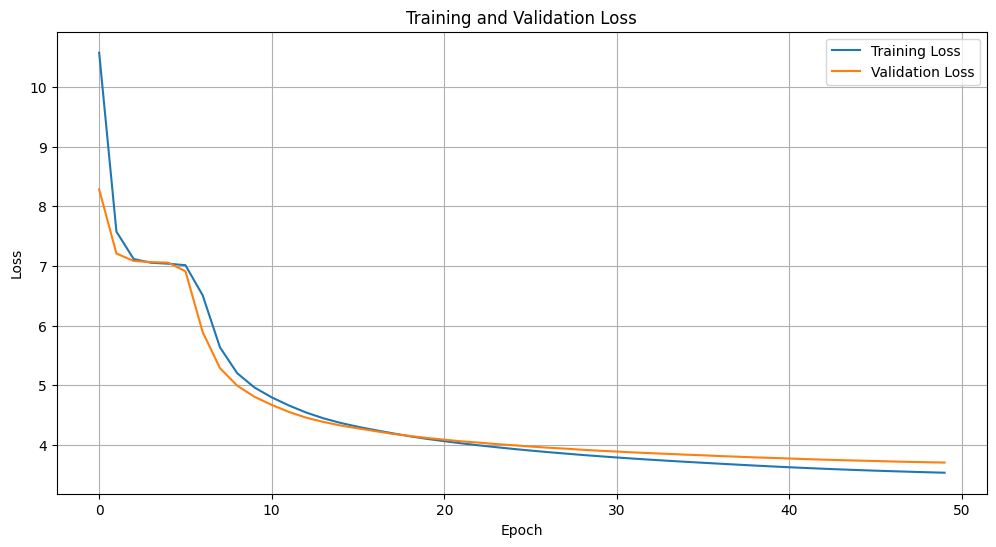

In [25]:
# @title **Etapa 7: Avaliação do histórico de treinamento**
# Plotar loss de treinamento e validação
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
# @title **Etapa 8: Função para Geração de Texto**
# ==================================

def generate_text(model, start_string, num_generate=200, temperature=0.5, max_line_length=80):
    """
    Gera texto automaticamente usando um modelo Transformer pré-treinado.

    Args:
        model: Modelo Transformer treinado.
        start_string: Frase inicial para iniciar a geração.
        num_generate: Número de tokens a serem gerados.
        temperature: Controla a criatividade das previsões (valores menores = mais determinístico).
        max_line_length: Número máximo de caracteres por linha para formatação.

    Returns:
        Texto gerado formatado como uma string com parágrafos e quebras de linha.
    """

    # Vetoriza a string inicial
    input_eval_tokens = vectorizer([start_string]).numpy()[0] # Obtem os tokens (1D array)

    # Mantém os últimos 'seq_length' tokens ou menos se for mais curto
    input_eval = tf.convert_to_tensor(input_eval_tokens[-seq_length:], dtype=tf.int64)

    text_generated = [] # Lista para armazenar as palavras geradas

    # model.reset_states() # Removed this line as it's not needed for Transformers
    # and causing the error
    for i in range(num_generate):
        # Adiciona a dimensão do batch (modelo espera batch_size=1)
        input_batch = tf.expand_dims(input_eval, 0) # Shape: (1, N) onde N <= seq_length

        # Faz a previsão (obtém logits)
        # Passar training=False é importante para desativar dropout, etc.
        predictions = model(input_batch, training=False) # Shape: (1, N, vocab_size)

        # Remove a dimensão de batch e pega os logits do *último* token previsto
        # predictions[:, -1, :] seleciona os logits para a próxima palavra após a sequência de entrada
        last_token_logits = predictions[0, -1, :] # Shape: (vocab_size,)

        # Aplica temperatura e amostra o ID do próximo token
        predicted_id = sample_with_temperature(last_token_logits, temperature)
        predicted_id_tensor = tf.constant([predicted_id], dtype=tf.int64) # Converte para Tensor

        # Adiciona o token previsto à sequência de entrada para a próxima iteração
        input_eval = tf.concat([input_eval, predicted_id_tensor], axis=0)

        # *** CORREÇÃO/MELHORIA CRÍTICA: Truncar contexto do início ***
        # Mantém apenas os últimos 'seq_length' tokens se a sequência crescer demais
        if tf.shape(input_eval)[0] > seq_length:
            input_eval = input_eval[-seq_length:]

        # Converte o token previsto de volta para palavra
        # Usar .numpy() para obter o valor do tensor id
        word = vectorizer.get_vocabulary()[predicted_id]
        # Lidar com token desconhecido [UNK] ou padding (se houver) - opcional
        if word == '[UNK]':
           word = '?' # Ou outra representação
        text_generated.append(word)

    # Formatar o texto gerado
    formatted_text = format_text(text_generated, max_line_length)
    return start_string + formatted_text # Removido '\n\n' extra

In [28]:
def sample_with_temperature(predictions, temperature=1.0):
    """Aplica temperatura e amostra um token dos logits."""
    if temperature <= 0: # Evitar divisão por zero e comportamento estranho
        temperature = 1.0 # Ou pode implementar amostragem argmax para temp=0

    # Ajusta os logits com a temperatura
    predictions_adjusted = predictions / temperature
    # Converte logits ajustados em probabilidades usando Softmax
    probabilities = tf.nn.softmax(predictions_adjusted)

    # Amostra um ID de token com base nas probabilidades
    # tf.random.categorical espera log-probabilidades para estabilidade numérica
    log_probabilities = tf.math.log(probabilities)
    # Adiciona dimensão de batch para categorical
    predicted_id = tf.random.categorical(log_probabilities[tf.newaxis, :], num_samples=1)
    predicted_id = predicted_id[0, 0].numpy() # Extrai o valor escalar do tensor

    return predicted_id

In [34]:
def format_text(words, max_line_length):
    """Formata uma lista de palavras em linhas com quebra automática."""
    formatted_lines = []
    current_line = ""
    for word in words:
        # Adiciona espaço antes da palavra, exceto no início da linha
        word_to_add = (" " if current_line else "") + word
        if len(current_line + word_to_add) > max_line_length:
            # Se exceder, adiciona a linha atual (sem espaços extras) e começa nova linha
            formatted_lines.append(current_line.strip())
            current_line = word # A palavra atual inicia a nova linha
        else:
            # Senão, adiciona a palavra à linha atual
            current_line += word_to_add

    if current_line: # Adiciona a última linha se não estiver vazia
        formatted_lines.append(current_line.strip())

    return "\n".join(formatted_lines)

# Exemplo de uso da geração
generated_text = generate_text(model, start_string='Romeo', num_generate=150, temperature=0.6)

# Exibir o texto gerado
print("\n--- Texto Gerado ---")
print(generated_text)
print("--------------------")


--- Texto Gerado ---
Romeoback shalt down makes tongue use At love, thing down down lord. When thought
lord. forth This part lord. use bid lord. WARWICK: SICINIUS: so, use down makes
SICINIUS: lord. MERCUTIO: use thought lord. lord. SICINIUS: SICINIUS: SICINIUS:
lord. forth thought Not love, valour At wander'd use lord. makes Not At love,
makes down At At At down love, thought Not makes makes thought makes love, love,
makes his thing Not hand thought WARWICK: LEONTES: Not Not WARWICK: Not Not
SICINIUS: Not SICINIUS: Not Not Not Not Not Not WARWICK: What SICINIUS: Not Not
Not WARWICK: lord, ? his brother ? ? EDWARD: my ? what is my ? ? my such ? I ?
knot, ? bloody ? our ? in ? ? ? ? ? ? I with ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? my
? ? in
--------------------


Como se vê, o texto gerado está completamente incoerente e e com caracteres repetidos. Esse é um problema comum quando o modelo não aprendeu padrões significativos da linguagem ou quando entra em um "modo" degenerado durante a geração.